In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon
import plotly.express as px
import plotly.graph_objects as go
import nbformat

from scipy.stats import ttest_ind, f_oneway,mannwhitneyu
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib_venn import venn2
import os
import scipy.cluster.hierarchy as sch
from scipy.stats import ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

In [2]:
target_CAFs=["FAP", "PDGFRA", "PDGFRB", "S100A4", "LRRC15", "IL1R1", "IL1R2","SMO"]
target_receptors_molecules=["TGFB1","TGFB2","TGFB3", "TGFBR1","TGFBR2","TGFBR3","IL6", "IL6R", "IL10RA","IL10RB", "CXCL8", "CXCL12", 
 "CCR5", "CXCR2", "CXCR1", "CXCR4", "CXCL10","CXCL9","HGF", "MET", "FGF1","FGF2","FGF7","FGF10", "FGFR1","FGFR2","FGFR3","FGFR4","IL11","HAS1","HAS2","HYAL1","HYAL2"]

In [3]:

fibr_gene_expression_modified=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged_new/fibroblasts_gene_expression_data_new_batch_merged_with_metadata.csv")
clinical_data=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/9_eyemt_patient_clinical_data_new.csv")
sample_metadata=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/batch_merged_geomx_metadata.csv")
fibr_gene_expression_modified["Patient"]=fibr_gene_expression_modified["Sample"].str.extract(r'(S\d+)')
#fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","PFS_quartile_b12"]],on="Patient", how="left")
#fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","OS_quartile_b12"]],on="Patient", how="left")
fibr_gene_expression_modified

,dcc_filename,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,...,Site,Annotation_cell,UMAP1_harmony_batch_corr,UMAP2_harmony_batch_corr,tSNE1_harmony_batch_corr,tSNE2_harmony_batch_corr,PFS_quartile,OS_quartile,HRP_status,BRCA_status
0,DSP-1001660016604-A-A02.dcc,1.395991,1.907436,1.506498,1.700645,-0.045271,2.111774,4.080095,1.987522,-0.088093,...,Omentum,CD8_Iba1,1.215215,-0.077432,-3.170091,-5.679086,1.0,1.0,1.0,0.0
1,DSP-1001660016604-A-A03.dcc,1.260101,1.487834,1.372068,0.897518,1.051446,1.981081,4.439861,1.858659,-0.088057,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,DSP-1001660016604-A-A04.dcc,1.224783,1.724003,1.333149,1.528053,-0.045955,1.932914,5.415247,1.805880,-0.088144,...,Omentum,CD8_CD11_Iba1,1.018313,0.150165,-3.133863,-5.250586,1.0,1.0,1.0,0.0
3,DSP-1001660016604-A-A05.dcc,1.032495,1.168011,1.440325,0.954786,-0.044855,1.752843,5.293798,1.926242,-0.088061,...,Omentum,CD8_CD11_Iba1,1.391849,0.083829,-3.781880,-5.211237,1.0,1.0,1.0,0.0
4,DSP-1001660016604-A-A06.dcc,0.885513,1.403719,0.997214,1.190924,-0.044885,2.324255,5.864764,1.482811,-0.088064,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,DSP-1001660037247-C-D01.dcc,1.437959,1.440393,1.436729,1.241617,-0.193169,1.637498,3.101474,1.641694,-0.090027,...,Omentum,CD4_CD8_Iba1,1.313707,-1.133519,2.208867,-8.009140,3.0,1.0,1.0,0.0
440,DSP-1001660037247-C-D02.dcc,0.945847,1.243403,0.944546,0.748442,0.529108,1.884311,5.777772,1.685343,-0.090014,...,Omentum,CD8_CD11_Iba1,-1.239031,-0.703740,4.600234,-4.362463,3.0,1.0,1.0,0.0
441,DSP-1001660037247-C-D03.dcc,-0.115866,0.009407,-0.109719,-0.209418,-0.136728,0.308744,7.235237,0.261484,-0.091188,...,Omentum,CD8_CD11_Iba1,-0.745955,3.245862,-0.746496,9.353104,3.0,1.0,1.0,0.0
442,DSP-1001660037247-C-D04.dcc,0.912336,1.440847,0.911072,-0.369284,-0.193441,1.110790,4.140232,1.641895,-0.090021,...,Omentum,CD8_CD11_Iba1,0.277125,0.801534,4.179252,-5.604464,3.0,1.0,1.0,0.0


In [11]:
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(sample_metadata[["Sample","NACT_status"]],on="Sample", how="left")
fibr_gene_expression_modified=fibr_gene_expression_modified.unique()
fibr_gene_expression_modified

: 

In [5]:
""""
fibr_gene_expression_modified=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged_new/fibroblasts_gene_expression_data_new_batch_merged_with_metadata.csv")
clinical_data=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/9_eyemt_patient_clinical_data_new.csv")
fibr_gene_expression_modified["Patient"]=fibr_gene_expression_modified["Sample"].str.extract(r'(S\d+)')
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","PFS_quartile_b12"]],on="Patient", how="left")
fibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","OS_quartile_b12"]],on="Patient", how="left")
"""

'"\nfibr_gene_expression_modified=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged_new/fibroblasts_gene_expression_data_new_batch_merged_with_metadata.csv")\nclinical_data=pd.read_csv("/Users/nikamikhailava/Desktop/batch_merged/9_eyemt_patient_clinical_data_new.csv")\nfibr_gene_expression_modified["Patient"]=fibr_gene_expression_modified["Sample"].str.extract(r\'(S\\d+)\')\nfibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","PFS_quartile_b12"]],on="Patient", how="left")\nfibr_gene_expression_modified=fibr_gene_expression_modified.merge(clinical_data[["Patient","OS_quartile_b12"]],on="Patient", how="left")\n'

In [6]:
sample_metadata["Sample"]

0      S053_post
1      S053_post
2      S053_post
3      S053_post
4      S053_post
         ...    
499    S333_pOme
500    S333_pOme
501    S333_pOme
502    S333_pOme
503    S333_pOme
Name: Sample, Length: 504, dtype: object

In [7]:
fibr_gene_expression_modified["Sample"]

0       S130_iOme
1       S130_iOme
2       S130_iOme
3       S130_iOme
4       S130_iOme
          ...    
7556    S333_pOme
7557    S333_pOme
7558    S333_pOme
7559    S333_pOme
7560    S333_pOme
Name: Sample, Length: 7561, dtype: object

In [8]:
fibr_gene_expression_modified.head(5)

,dcc_filename,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,...,Annotation_cell,UMAP1_harmony_batch_corr,UMAP2_harmony_batch_corr,tSNE1_harmony_batch_corr,tSNE2_harmony_batch_corr,PFS_quartile,OS_quartile,HRP_status,BRCA_status,NACT_status_y
0,DSP-1001660016604-A-A02.dcc,1.395991,1.907436,1.506498,1.700645,-0.045271,2.111774,4.080095,1.987522,-0.088093,...,CD8_Iba1,1.215215,-0.077432,-3.170091,-5.679086,1.0,1.0,1.0,0.0,post
1,DSP-1001660016604-A-A02.dcc,1.395991,1.907436,1.506498,1.700645,-0.045271,2.111774,4.080095,1.987522,-0.088093,...,CD8_Iba1,1.215215,-0.077432,-3.170091,-5.679086,1.0,1.0,1.0,0.0,post
2,DSP-1001660016604-A-A02.dcc,1.395991,1.907436,1.506498,1.700645,-0.045271,2.111774,4.080095,1.987522,-0.088093,...,CD8_Iba1,1.215215,-0.077432,-3.170091,-5.679086,1.0,1.0,1.0,0.0,post
3,DSP-1001660016604-A-A02.dcc,1.395991,1.907436,1.506498,1.700645,-0.045271,2.111774,4.080095,1.987522,-0.088093,...,CD8_Iba1,1.215215,-0.077432,-3.170091,-5.679086,1.0,1.0,1.0,0.0,post
4,DSP-1001660016604-A-A02.dcc,1.395991,1.907436,1.506498,1.700645,-0.045271,2.111774,4.080095,1.987522,-0.088093,...,CD8_Iba1,1.215215,-0.077432,-3.170091,-5.679086,1.0,1.0,1.0,0.0,post


In [9]:
sample_metadata= fibr_gene_expression_modified[["Sample","NACT_status"]].drop_duplicates().set_index("Sample")

KeyError: "['NACT_status'] not in index"

In [ ]:
stroma_gene_expression=fibr_gene_expression_modified[fibr_gene_expression_modified['Segment']=='stroma']
average_stroma_gene_expression=stroma_gene_expression.groupby('Sample')[target_CAFs+target_receptors_molecules].mean()
average_stroma_gene_expression = average_stroma_gene_expression.join(sample_metadata)
average_stroma_gene_expression.head(5)


,FAP,PDGFRA,PDGFRB,S100A4,LRRC15,IL1R1,IL1R2,SMO,TGFB1,TGFB2,...,FGFR1,FGFR2,FGFR3,FGFR4,IL11,HAS1,HAS2,HYAL1,HYAL2,NACT_status
Sample,,,,,,,,,,,,,,,,,,,,,
S015_post,4.207266,4.373742,3.830773,2.507247,3.973624,3.090736,0.923488,1.086929,2.239990,2.192088,...,3.205101,0.991744,0.299681,0.508378,1.980160,2.647840,2.295521,1.431089,1.860142,post
S015_pre,4.691707,4.062607,3.794440,2.253992,3.370159,3.906483,1.332299,1.282178,2.284189,2.708479,...,2.882796,1.556014,0.717385,1.002197,2.554963,3.242793,2.690586,1.735281,2.179100,pre
S027_post,4.339291,4.852624,4.743002,2.770996,3.501261,3.721203,1.183972,1.461542,1.931747,2.083176,...,3.409909,0.610212,0.239314,1.480520,2.641902,3.353829,2.813274,1.622922,2.135830,post
S027_pre,3.991612,3.689627,3.016678,2.228345,4.126285,2.933034,0.839076,0.853989,2.029707,2.025435,...,2.505830,1.168566,0.375664,-0.198721,1.660973,2.341774,1.860757,1.249905,2.273118,pre
S032_post,4.170236,3.908524,3.471096,2.312855,4.258186,3.505226,0.953693,0.989592,1.927891,1.702305,...,2.644436,1.112555,0.421874,0.060000,1.831252,2.667713,2.127929,1.384202,1.895738,post


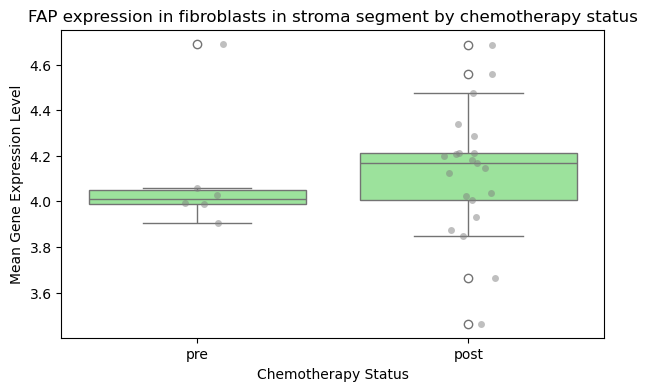

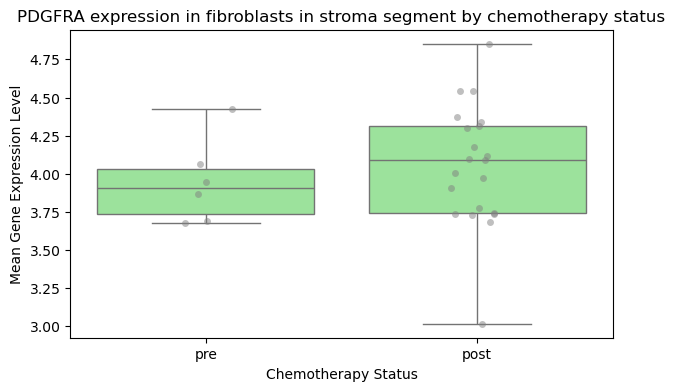

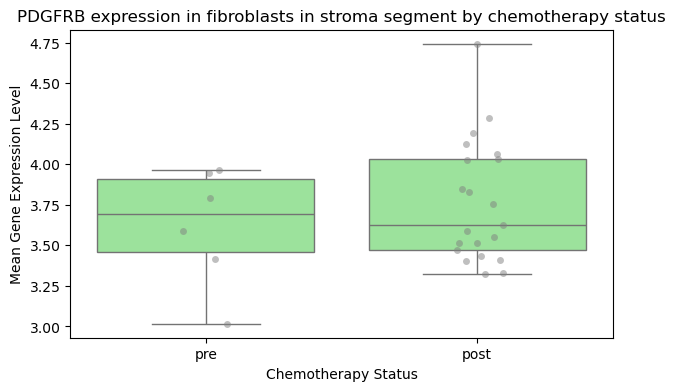

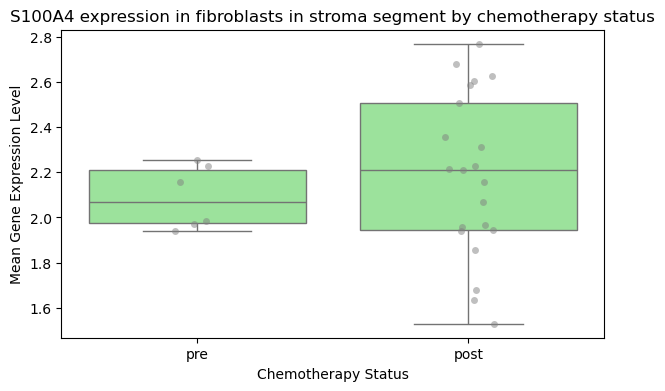

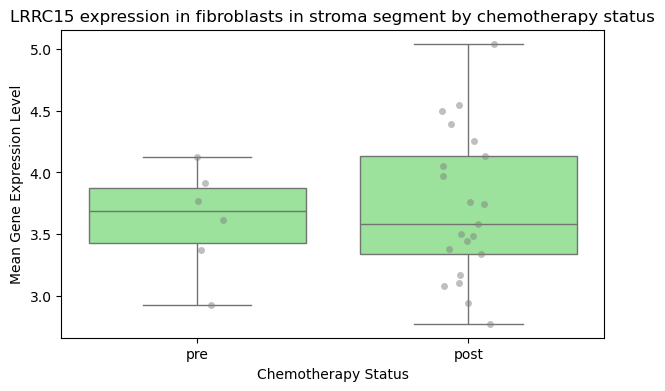

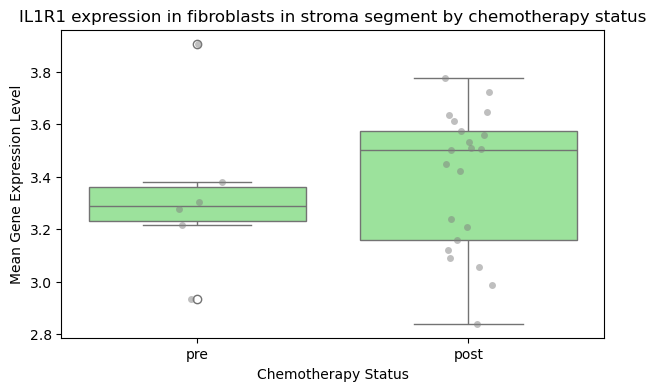

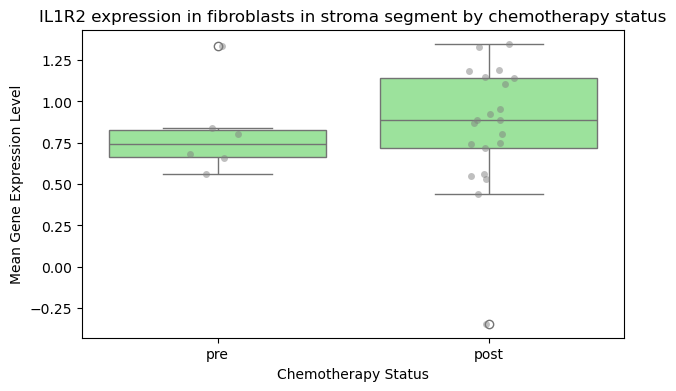

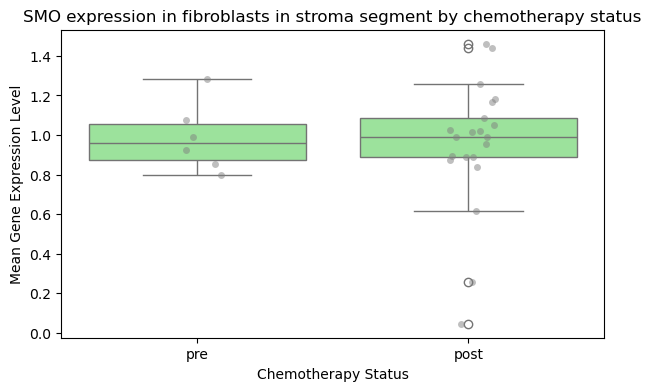

In [ ]:
for gene in target_CAFs:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="NACT_status",y=gene,data=average_stroma_gene_expression, color='lightgreen',order=["pre","post"])
    sns.stripplot(x="NACT_status", y=gene, data=average_stroma_gene_expression, color='grey', alpha=0.5, jitter=True)
    plt.title(f"{gene} expression in fibroblasts in stroma segment by chemotherapy status")
    plt.xlabel("Chemotherapy Status")
    plt.ylabel("Mean Gene Expression Level")
    plt.show()

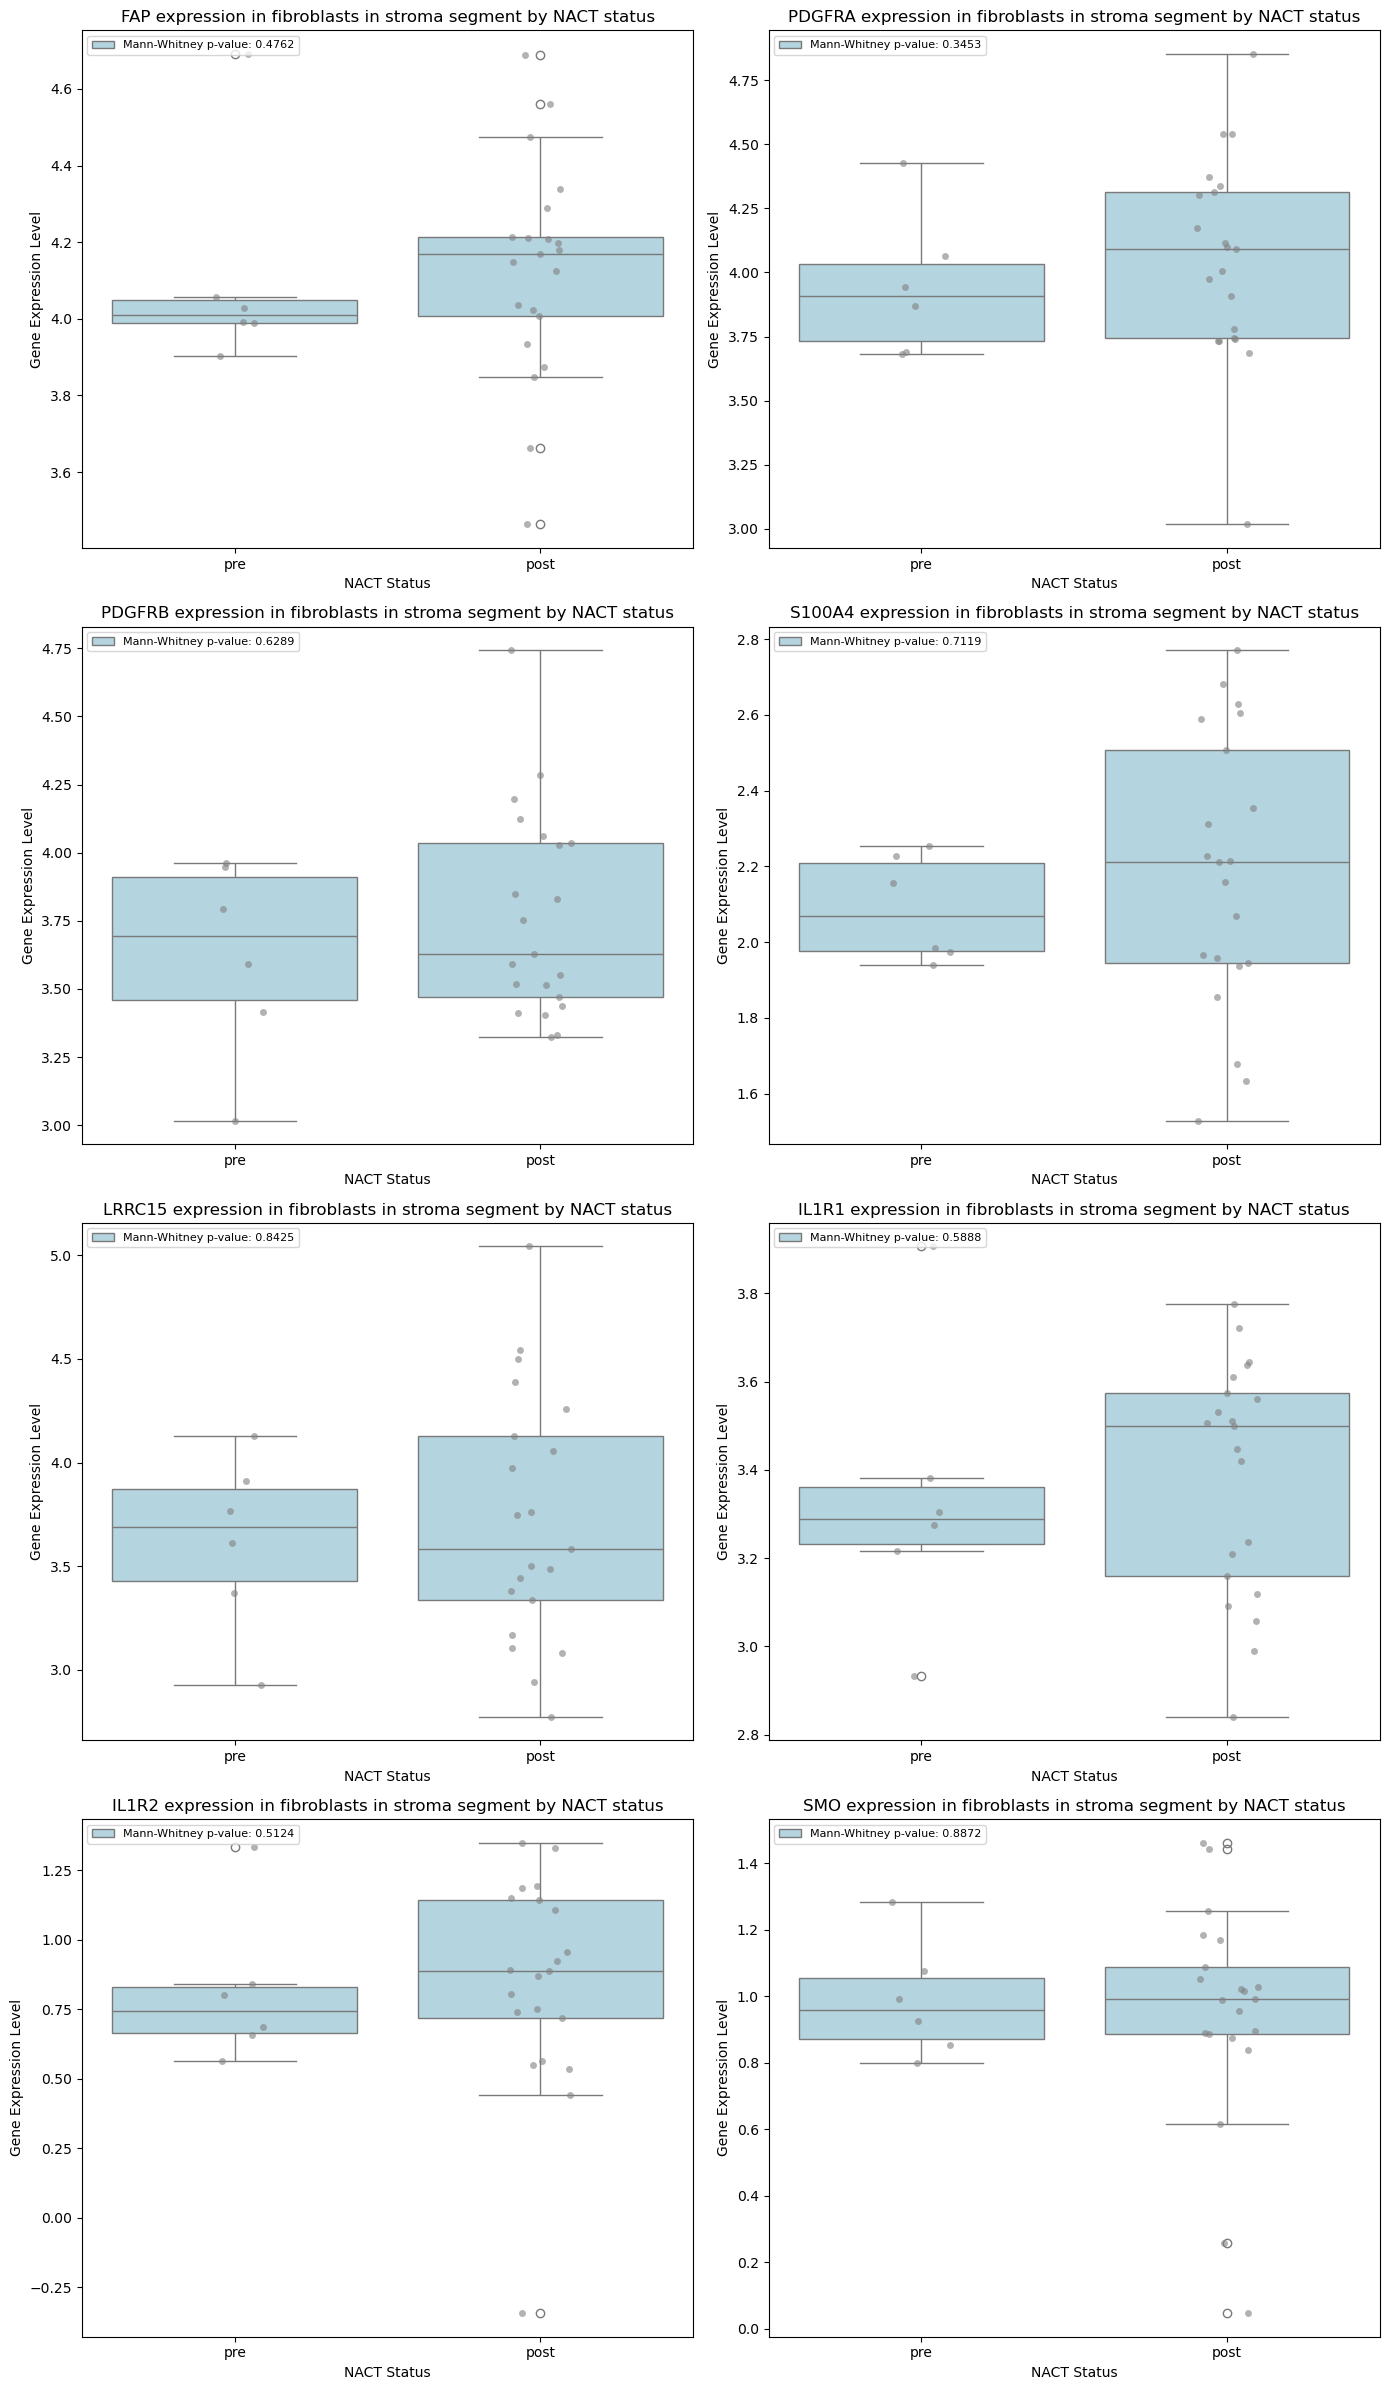

In [ ]:
# Determine the number of plots
num_plots = len(target_CAFs)

# Determine the number of rows and columns for subplots
# Here, we'll use a 2-column layout and calculate the number of rows
ncols = 2
nrows = (num_plots + 1) // ncols  # This will ensure an extra row if needed

# Create the subplots grid
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 6))

# Flatten axes array if there are multiple rows and columns
axes = axes.flatten()

for i, gene in enumerate(target_CAFs):
    group_low = average_stroma_gene_expression[average_stroma_gene_expression["NACT_status"] == "pre"][gene]
    group_high = average_stroma_gene_expression[average_stroma_gene_expression["NACT_status"] == "post"][gene]

    # Perform the Mann-Whitney U test
    stat, p_value = mannwhitneyu(group_low, group_high, alternative='two-sided')
    
    # Create the plot
    sns.boxplot(x="NACT_status", y=gene, data=average_stroma_gene_expression, color='lightblue', order=["pre", "post"], ax=axes[i])
    sns.stripplot(x="NACT_status", y=gene, data=average_stroma_gene_expression, color='grey', alpha=0.6, jitter=True, order=["pre", "post"], ax=axes[i])
    
    # Set titles and labels for each subplot
    axes[i].set_title(f"{gene} expression in fibroblasts in stroma segment by NACT status")
    axes[i].set_xlabel("NACT Status")
    axes[i].set_ylabel("Gene Expression Level")
    
    # Add p-value to the legend
    axes[i].legend([f'Mann-Whitney p-value: {p_value:.4f}'], loc='upper left', fontsize=8)

# Adjust layout to prevent overlap and make sure labels are visible
plt.tight_layout()
plt.show()


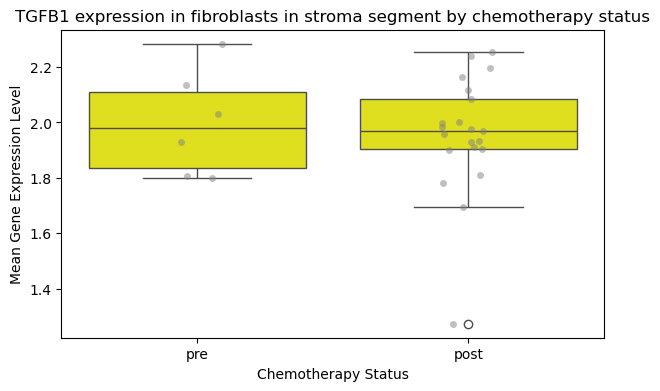

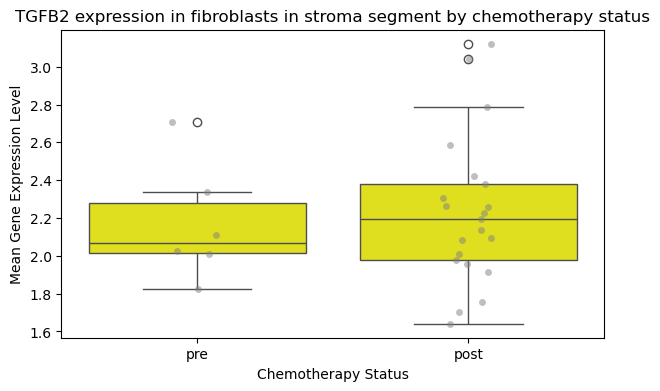

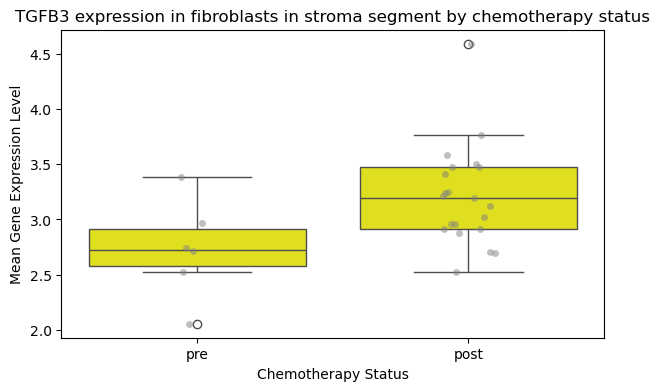

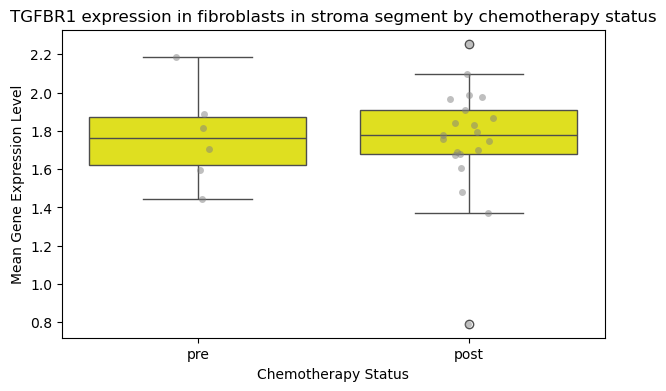

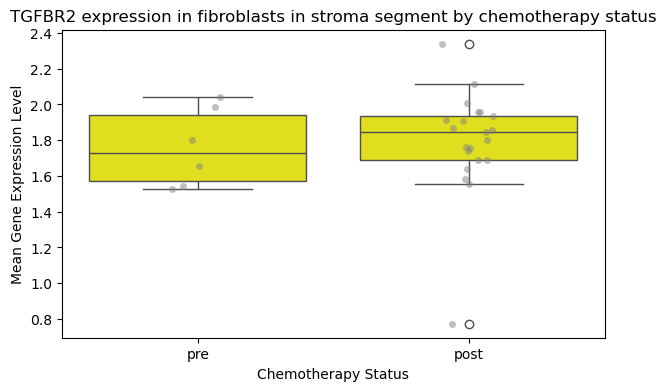

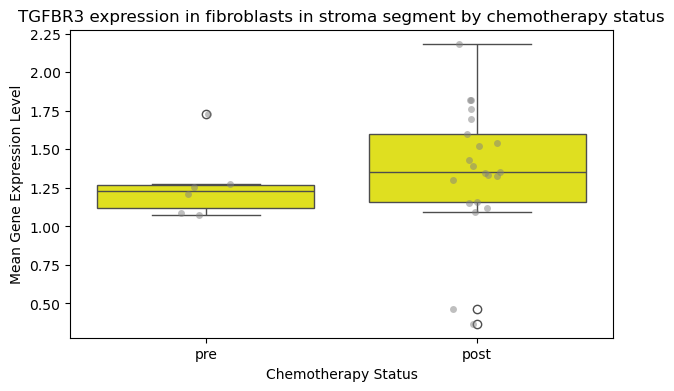

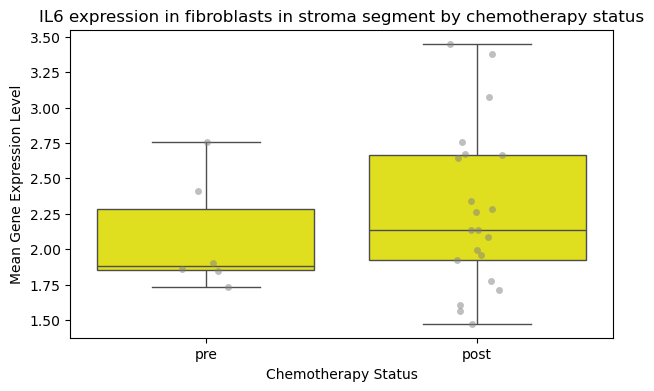

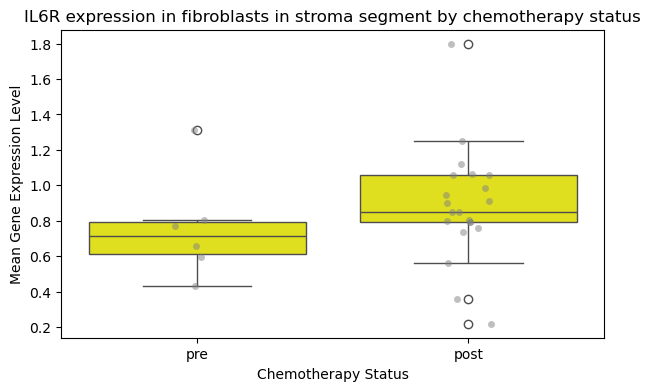

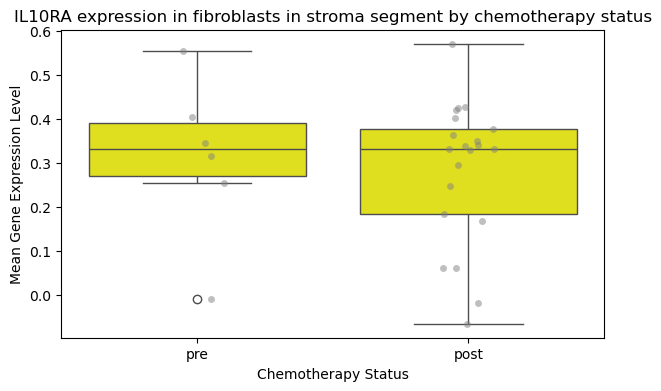

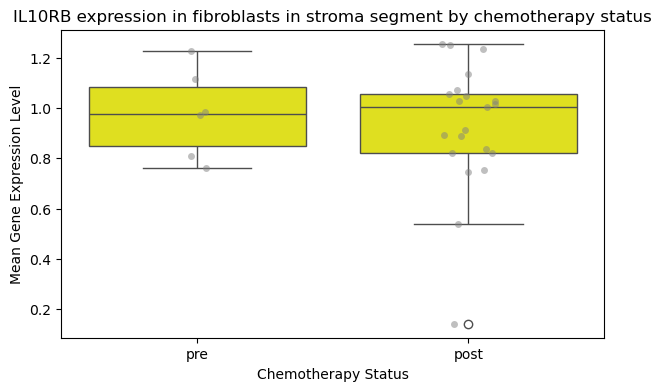

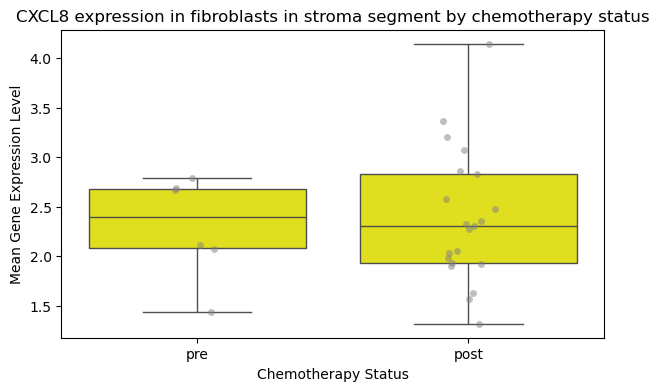

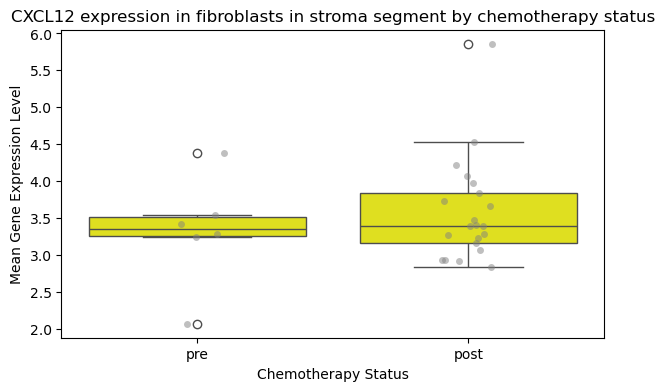

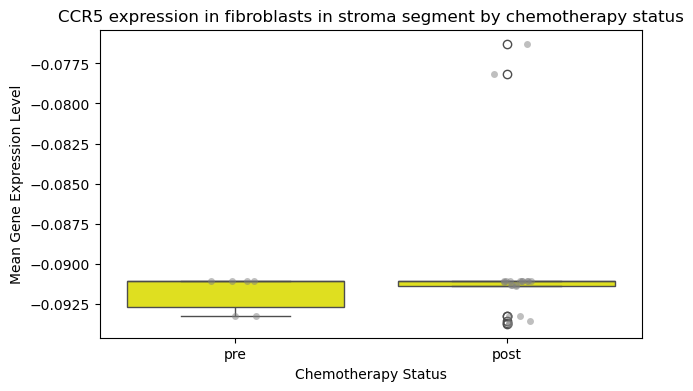

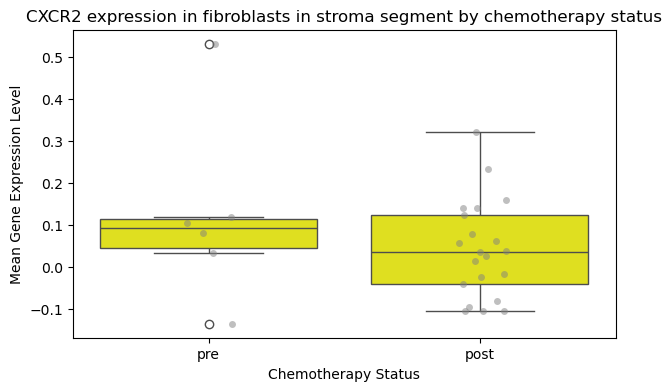

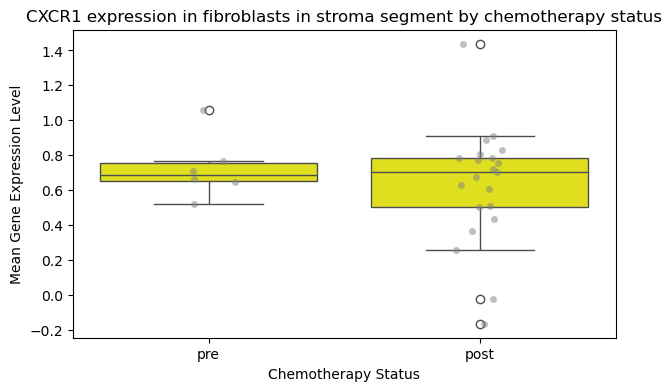

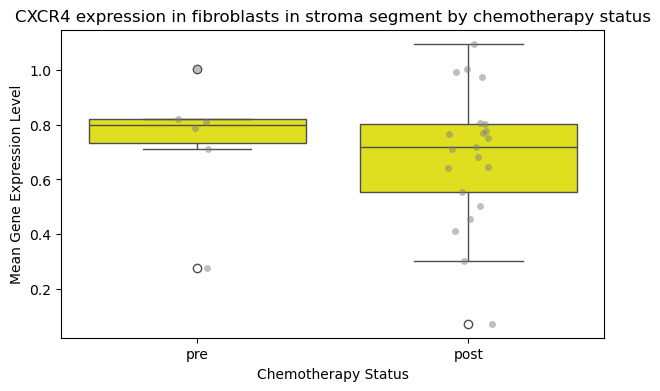

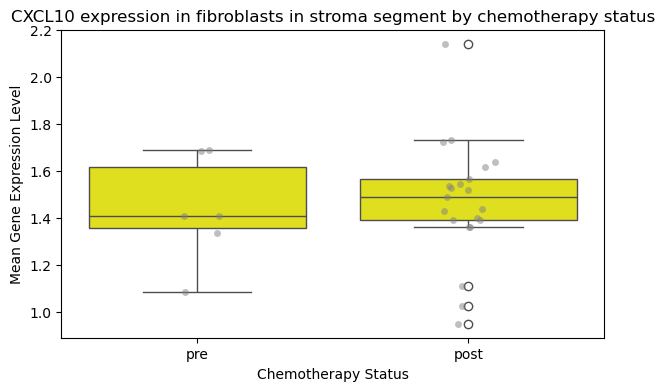

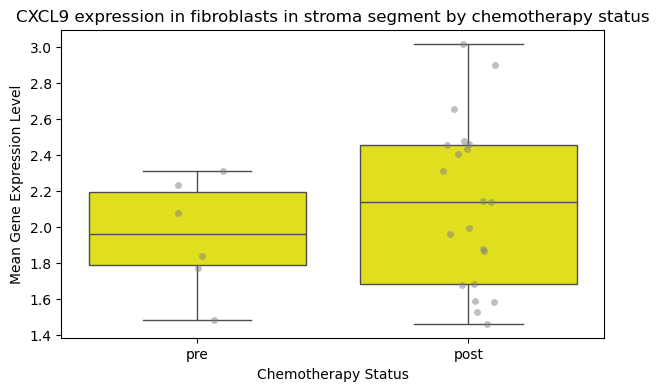

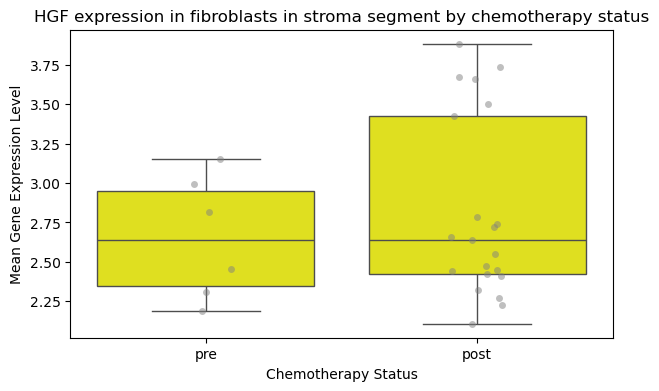

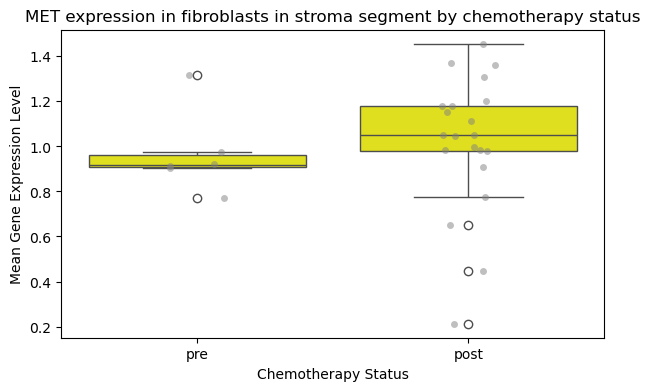

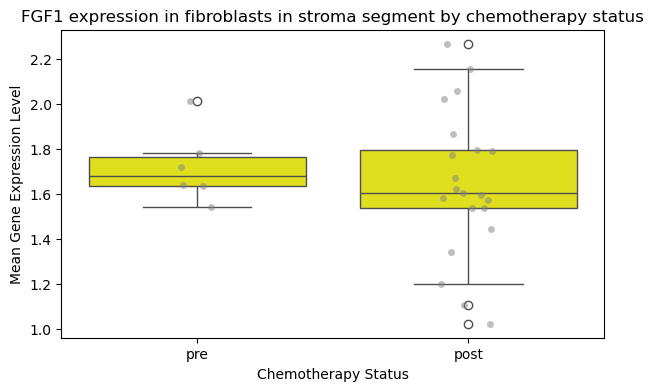

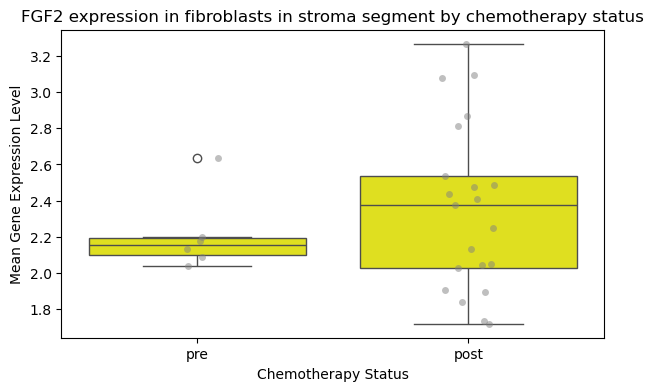

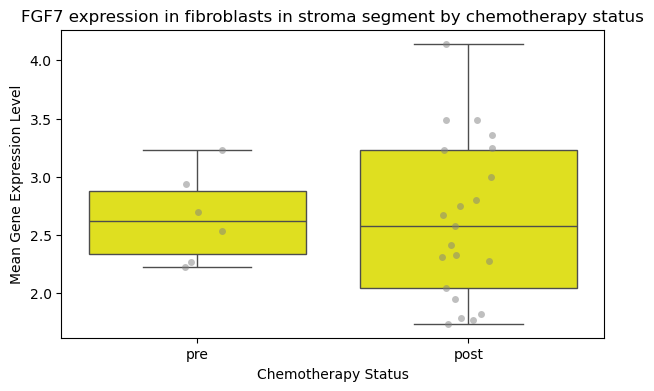

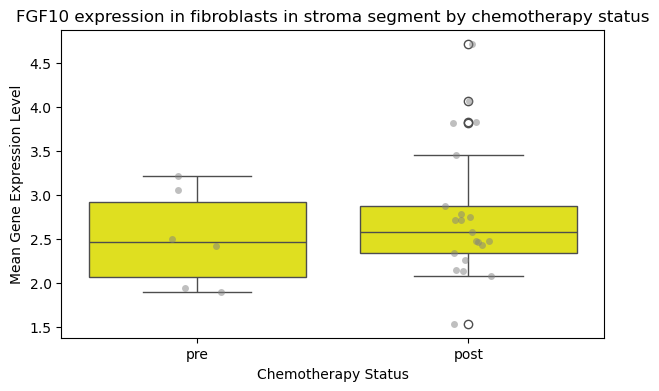

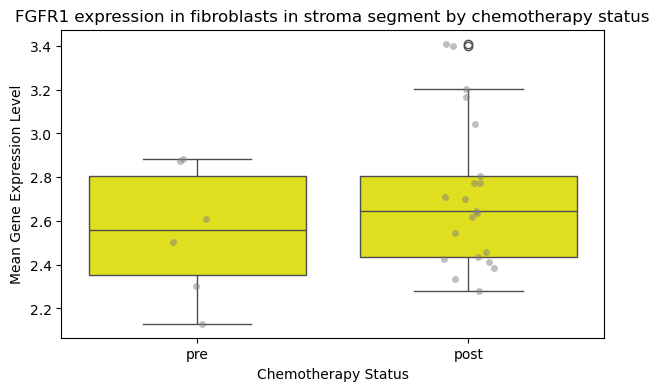

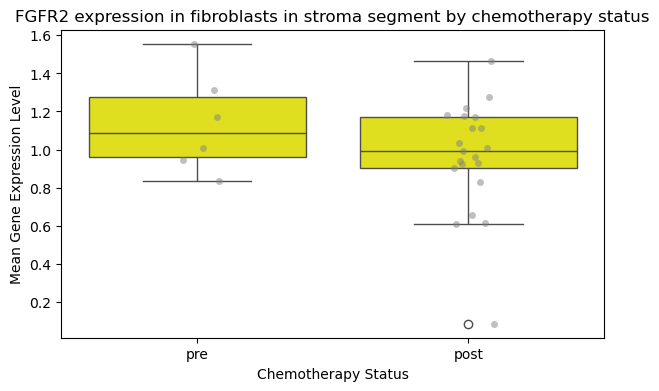

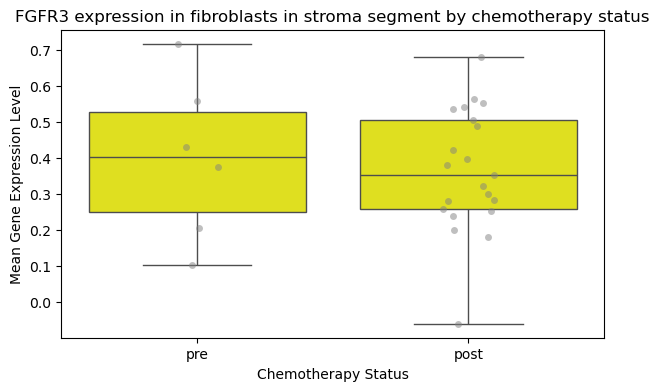

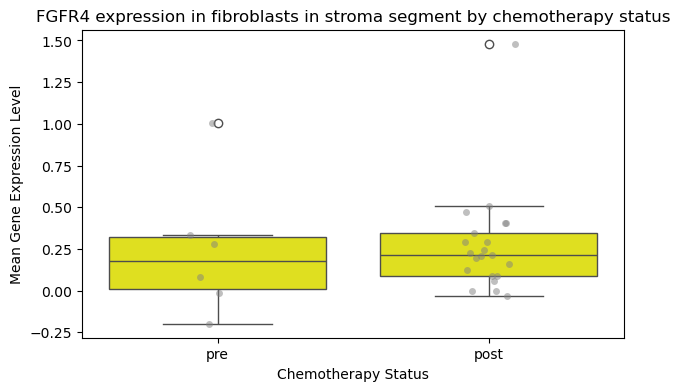

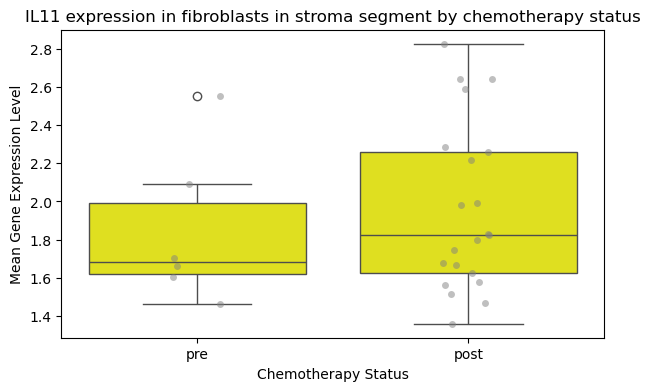

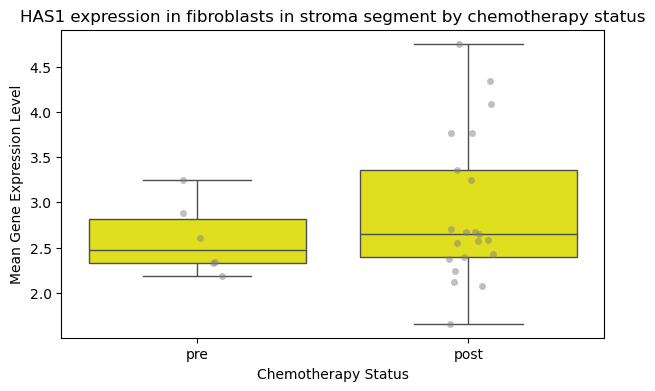

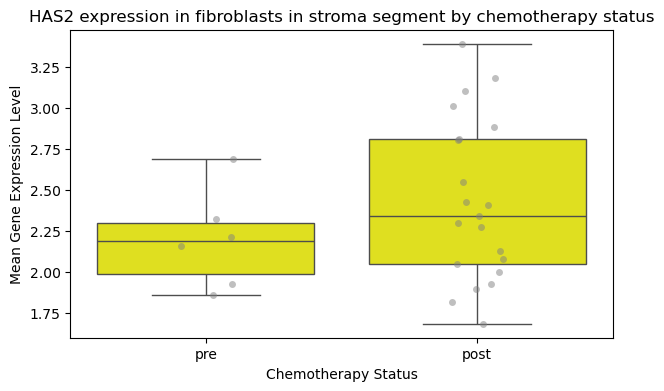

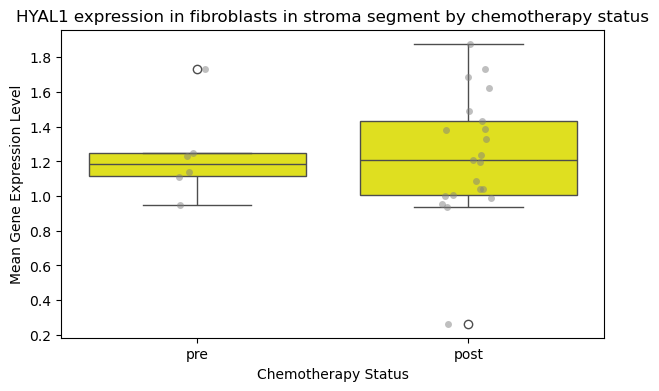

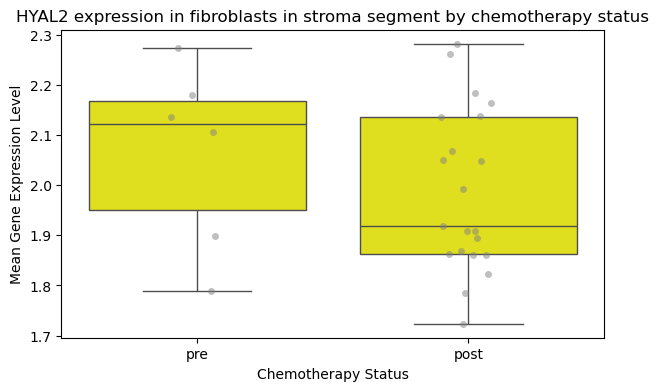

In [ ]:
for gene in target_receptors_molecules:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="NACT_status",y=gene,data=average_stroma_gene_expression, color='yellow',order=["pre","post"])
    sns.stripplot(x="NACT_status", y=gene, data=average_stroma_gene_expression, color='grey', alpha=0.5, jitter=True)
    plt.title(f"{gene} expression in fibroblasts in stroma segment by chemotherapy status")
    plt.xlabel("Chemotherapy Status")
    plt.ylabel("Mean Gene Expression Level")
    plt.show()